In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.stats import norm
import numpy as np


C:\Users\fzmaj\AppData\Local\Temp\ipykernel_18880\2807143247.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CheckInHour'] = pd.to_datetime(df['CheckInTime']).dt.hour
C:\Users\fzmaj\AppData\Local\Temp\ipykernel_18880\2807143247.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CheckOutHour'] = pd.to_datetime(df['CheckOutTime']).dt.hour


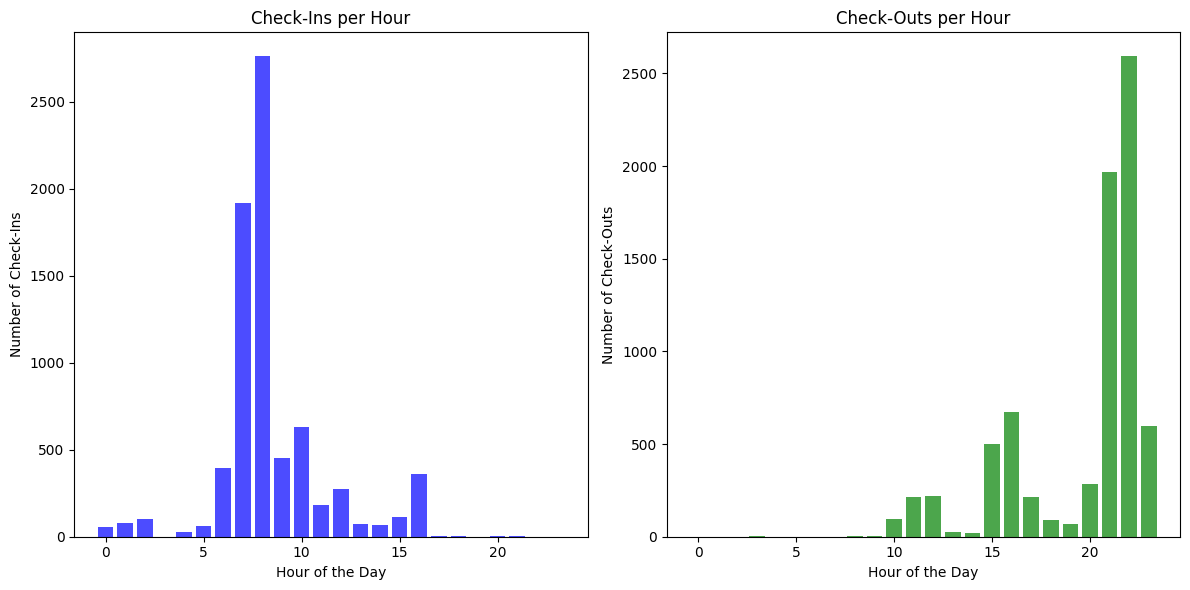

In [6]:
# Load dataset
get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/processed/3339_alwadi'))
csv_file = '3339_alwadi_transformation_data.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

DSet = pd.read_csv(absolute_path)

# Convert 'CheckInTime' and 'CheckOutTime' from HH:MM format to minutes since midnight
DSet['CheckInHour'] = pd.to_datetime(DSet['CheckInTime']).dt.hour 
DSet['CheckOutHour'] = pd.to_datetime(DSet['CheckOutTime']).dt.hour 


# Count check-ins per hour
check_in_counts = DSet['CheckInHour'].value_counts().sort_index()

# Count check-outs per hour
check_out_counts = DSet['CheckOutHour'].value_counts().sort_index()

# Create a DataFrame for plotting
hours = range(24)
check_in_counts = check_in_counts.reindex(hours, fill_value=0)
check_out_counts = check_out_counts.reindex(hours, fill_value=0)

# Plot results
plt.figure(figsize=(12, 6))

# Plot Check-In counts
plt.subplot(1, 2, 1)
plt.bar(check_in_counts.index, check_in_counts.values, color='blue', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Ins')
plt.title('Check-Ins per Hour')

# Plot Check-Out counts
plt.subplot(1, 2, 2)
plt.bar(check_out_counts.index, check_out_counts.values, color='green', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Outs')
plt.title('Check-Outs per Hour')

plt.tight_layout()
plt.show()


In [10]:
# Convert CheckInTime to minutes since midnight
def time_to_minutes(t):
    h, m, s = map(int, t.split(':'))
    return h * 60 + m + s / 60  # Convert seconds to minutes

DSet['CheckInMinutes'] = DSet['CheckInTime'].apply(time_to_minutes)
DSet['CheckOutMinutes'] = DSet['CheckOutTime'].apply(time_to_minutes)

# Feature engineering: Create features for clustering
features = DSet[['CheckInMinutes']] #, 'CheckOutMinutes']].values
features = StandardScaler().fit_transform(features)  # Normalize features

# K-Means Clustering
def optimal_k_means(features):
    silhouette_scores = []
    k_range = range(2, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(features)
        labels = kmeans.labels_
        silhouette_avg = silhouette_score(features, labels)
        silhouette_scores.append(silhouette_avg)
    optimal_k = k_range[np.argmax(silhouette_scores)]
    return optimal_k



8
0.7580094718484032


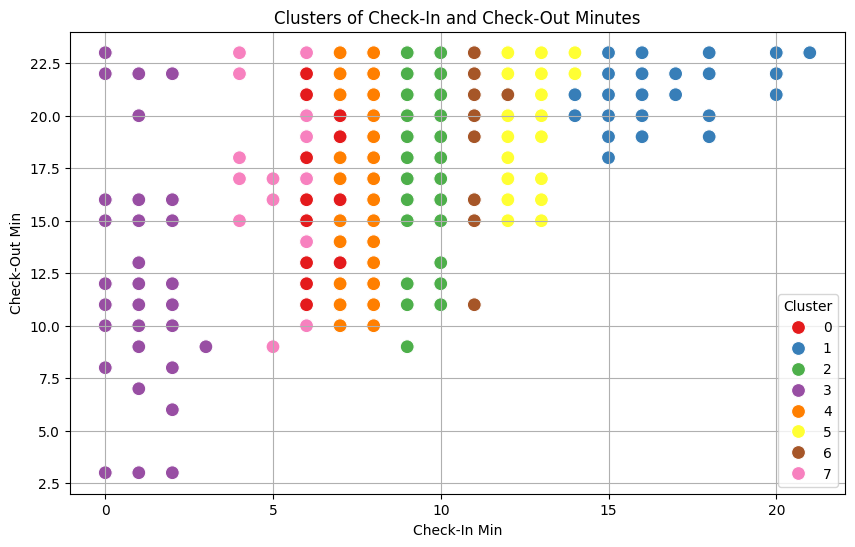

In [11]:
optimal_k = optimal_k_means(features)

print(optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
DSet['cluster'] = kmeans.fit_predict(features)

silhouette_avg = silhouette_score(features, df['cluster'])
print(silhouette_avg)
# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CheckInHour', y='CheckOutHour', hue=df['cluster'], data=df, palette='Set1', s=100)
plt.title('Clusters of Check-In and Check-Out Minutes')
plt.xlabel('Check-In Min')
plt.ylabel('Check-Out Min')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


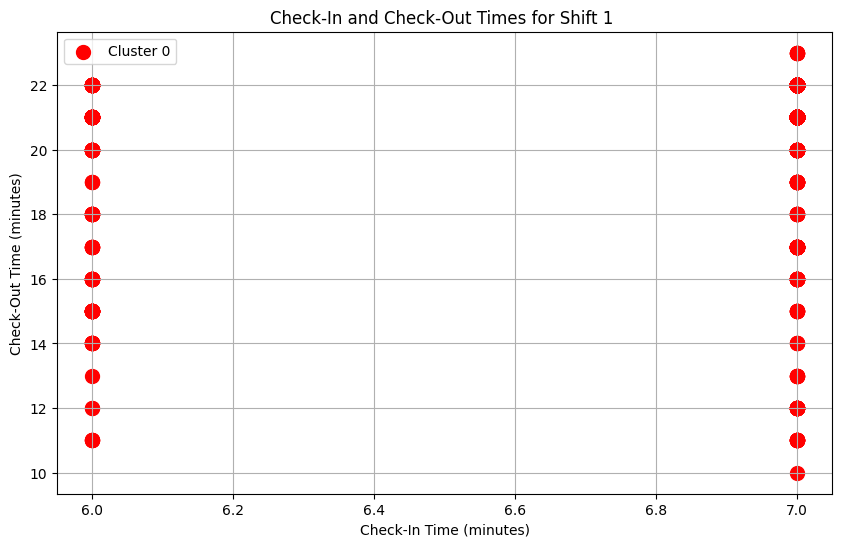

In [12]:
# Filter the DataFrame for Cluster 0
cluster_df = DSet[DSet['cluster'] == 0]
#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='red', label='Cluster 0', s=100)
plt.title('Check-In and Check-Out Times for Shift 1 ')
plt.xlabel('Check-In Time (minutes)')
plt.ylabel('Check-Out Time (minutes)')
plt.grid(True)
plt.legend()
plt.show()

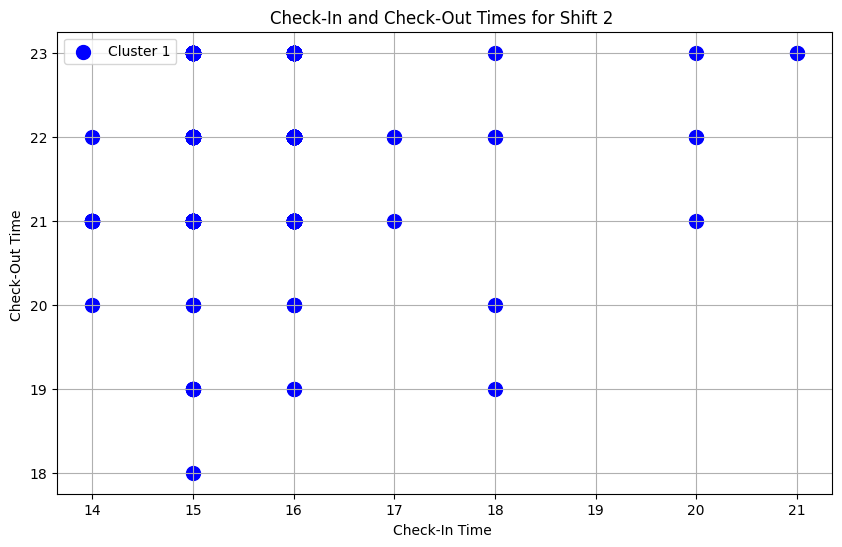

In [13]:
cluster_df = DSet[DSet['cluster'] == 1]
#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='blue', label='Cluster 1', s=100)
plt.title('Check-In and Check-Out Times for Shift 2 ')
plt.xlabel('Check-In Time ')
plt.ylabel('Check-Out Time ')
plt.grid(True)
plt.legend()
plt.show()

In [14]:
employee_count_per_cluster = DSet.groupby('cluster')['EmployeeId'].nunique().reset_index()

# Rename columns for clarity
employee_count_per_cluster.columns = ['cluster', 'NumberOfEmployees']

# Print the result
print(employee_count_per_cluster)

   cluster  NumberOfEmployees
0        0                 49
1        1                100
2        2                 54
3        3                 36
4        4                121
5        5                 43
6        6                 55
7        7                 21


In [19]:

# Calculate start and end hours for each cluster
# Calculate statistics for each cluster
cluster_summary = DSet.groupby('cluster').agg({
    'CheckInHour': ['mean', 'min', 'max'],
    'CheckOutHour': ['mean', 'min', 'max']
}).reset_index()

# Flatten MultiIndex columns
cluster_summary.columns = ['Cluster', 'CheckInHour_Mean', 'CheckInHour_Min', 'CheckInHour_Max',
                           'CheckOutHour_Mean', 'CheckOutHour_Min', 'CheckOutHour_Max']

# Print the summary
print(cluster_summary)


   Cluster  CheckInHour_Mean  CheckInHour_Min  CheckInHour_Max  \
0        0          6.844136                6                7   
1        1         15.800000               14               21   
2        2          9.625800                9               10   
3        3          1.208511                0                3   
4        4          7.804230                7                9   
5        5         12.818584               12               14   
6        6         11.328431               10               12   
7        7          5.589928                4                6   

   CheckOutHour_Mean  CheckOutHour_Min  CheckOutHour_Max  
0          20.151235                10                23  
1          21.710891                18                23  
2          18.852878                 9                23  
3          12.357447                 3                23  
4          20.095987                10                23  
5          19.469027                15             

Attendance Counts for Each 30-Minute Interval:
          TimeInterval  Count  MinutesSinceMidnight
0  2024-09-13 00:00:00     40                     0
1  2024-09-13 00:30:00     15                    30
2  2024-09-13 01:00:00     31                    60
3  2024-09-13 01:30:00     46                    90
4  2024-09-13 02:00:00     99                   120
5  2024-09-13 02:30:00      3                   150
6  2024-09-13 03:00:00      1                   180
7  2024-09-13 04:00:00     25                   240
8  2024-09-13 04:30:00      1                   270
9  2024-09-13 05:00:00      7                   300
10 2024-09-13 05:30:00     55                   330
11 2024-09-13 06:00:00    180                   360
12 2024-09-13 06:30:00    212                   390
13 2024-09-13 07:00:00   1043                   420
14 2024-09-13 07:30:00    876                   450
15 2024-09-13 08:00:00   2654                   480
16 2024-09-13 08:30:00    106                   510
17 2024-09-13 09:

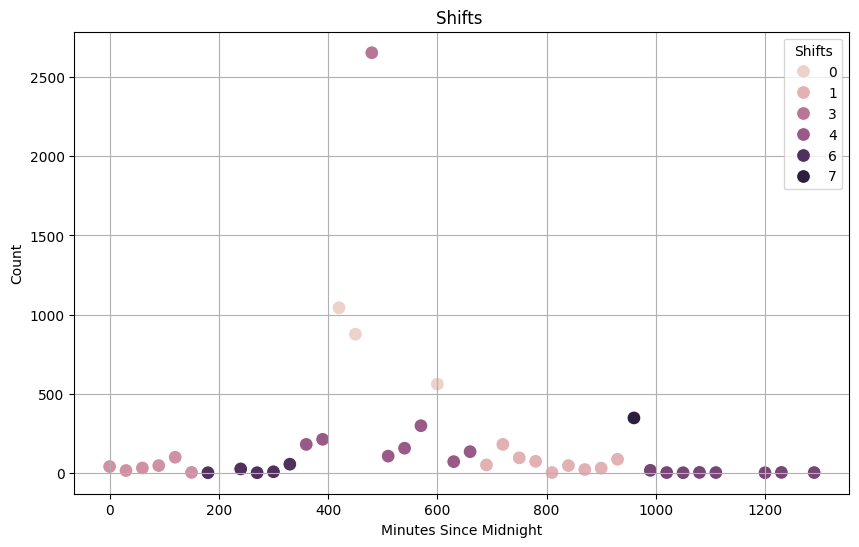

In [20]:
# Convert CheckInTime to datetime format and round to the nearest 30 minutes
DSet['CheckInTime'] = pd.to_datetime(DSet['CheckInTime'], format='%H:%M:%S').dt.time

def round_to_nearest_30_minutes(time):
    # Convert time to minutes, round to nearest 30, then convert back to time
    minute = (time.minute // 30) * 30
    return time.replace(minute=minute, second=0, microsecond=0)

# Apply rounding function
DSet['RoundedCheckInTime'] = DSet['CheckInTime'].apply(lambda x: round_to_nearest_30_minutes(pd.Timestamp.combine(pd.Timestamp.today(), x)))

# Count occurrences for each 30-minute interval
attendance_counts = DSet['RoundedCheckInTime'].value_counts().sort_index()

# Convert to DataFrame for clustering
attendance_df = attendance_counts.reset_index()
attendance_df.columns = ['TimeInterval', 'Count']

print("Attendance Counts for Each 30-Minute Interval:")
#print(attendance_df)

# Convert TimeInterval to numerical feature (e.g., minutes since midnight)
def time_to_minutes(time_obj):
    # Ensure the time_obj is in proper format (HH:MM)
    if isinstance(time_obj, pd.Timestamp):
        hours, minutes = time_obj.hour, time_obj.minute
    else:
        hours, minutes = map(int, str(time_obj).split(':'))
    return hours * 60 + minutes

attendance_df['MinutesSinceMidnight'] = attendance_df['TimeInterval'].apply(time_to_minutes)

print(attendance_df)


# Features for clustering
features = attendance_df[['MinutesSinceMidnight', 'Count']]

# Normalize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
# K-Means Clustering
def optimal_k_means(features):
    silhouette_scores = []
    k_range = range(2, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(features)
        labels = kmeans.labels_
        silhouette_avg = silhouette_score(features, labels)
        silhouette_scores.append(silhouette_avg)
    optimal_k = k_range[np.argmax(silhouette_scores)]
    return optimal_k

#optimal_k = optimal_k_means(scaled_features)
optimal_k = 8
print(optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
attendance_df['Shifts'] = kmeans.fit_predict(features)

silhouette_avg = silhouette_score(features, attendance_df['Shifts'])
print(silhouette_avg)
# Plot the clusters

plt.figure(figsize=(10, 6))

#for i in range(optimal_k):
#    cluster_data = attendance_df[attendance_df['Shifts'] == i]
#    plt.scatter(cluster_data['MinutesSinceMidnight'], cluster_data['Count'], label=f'Shifts {i}')
#    plt.plot(cluster_data['MinutesSinceMidnight'], cluster_data['Count'], linestyle='-', marker='o')


sns.scatterplot(x='MinutesSinceMidnight', y='Count', hue=attendance_df['Shifts'], data=attendance_df, s=100)
plt.title('Shifts ')
plt.xlabel('Minutes Since Midnight')
plt.ylabel('Count')
plt.legend(title='Shifts')
plt.grid(True)
plt.show()



Attendance Counts for Each 30-Minute Interval:
          TimeInterval  Count  HoursSinceMidnight
0  2024-09-13 00:00:00     55                   0
1  2024-09-13 01:00:00     77                   1
2  2024-09-13 02:00:00    102                   2
3  2024-09-13 03:00:00      1                   3
4  2024-09-13 04:00:00     26                   4
5  2024-09-13 05:00:00     62                   5
6  2024-09-13 06:00:00    392                   6
7  2024-09-13 07:00:00   1919                   7
8  2024-09-13 08:00:00   2760                   8
9  2024-09-13 09:00:00    454                   9
10 2024-09-13 10:00:00    632                  10
11 2024-09-13 11:00:00    184                  11
12 2024-09-13 12:00:00    275                  12
13 2024-09-13 13:00:00     75                  13
14 2024-09-13 14:00:00     67                  14
15 2024-09-13 15:00:00    116                  15
16 2024-09-13 16:00:00    363                  16
17 2024-09-13 17:00:00      3                  17
18 

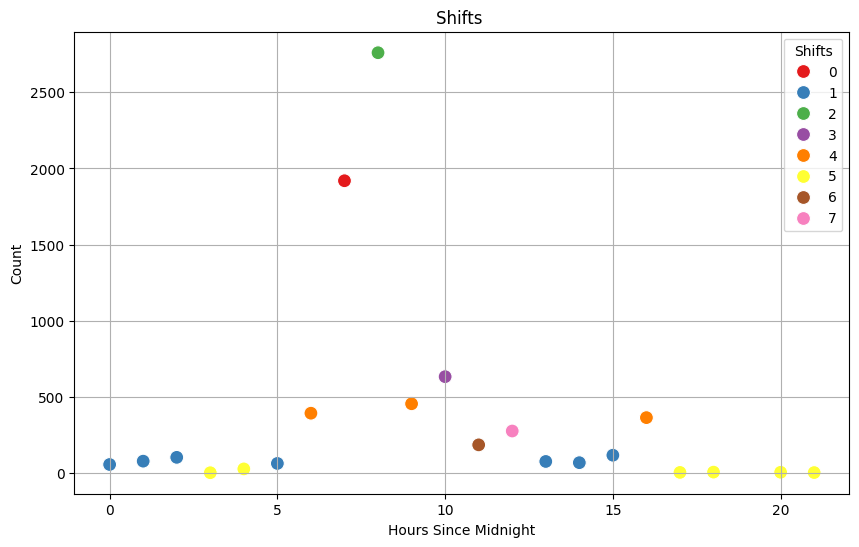

In [21]:
# Convert CheckInTime to datetime format and round to the nearest 30 minutes
DSet['CheckInTime'] = pd.to_datetime(DSet['CheckInTime'], format='%H:%M:%S').dt.time

# Function to round times to the nearest hour
def round_to_nearest_hour(time):
    hour = time.hour
    return time.replace(minute=0, second=0, microsecond=0)

# Apply rounding function
DSet['RoundedCheckInTime_H'] = DSet['CheckInTime'].apply(lambda x: round_to_nearest_hour(pd.Timestamp.combine(pd.Timestamp.today(), x)))

# Count occurrences for each 30-minute interval
attendance_counts_H = DSet['RoundedCheckInTime_H'].value_counts().sort_index()

# Convert to DataFrame for clustering
attendance_df_H = attendance_counts_H.reset_index()
attendance_df_H.columns = ['TimeInterval', 'Count']

print("Attendance Counts for Each 30-Minute Interval:")
#print(attendance_df)
# Convert TimeInterval to numerical feature (e.g., hours since midnight)
def time_to_hours(time_obj):
    return time_obj.hour

attendance_df_H['HoursSinceMidnight'] = attendance_df_H['TimeInterval'].apply(time_to_hours)

print(attendance_df_H)


# Features for clustering
features = attendance_df_H[['HoursSinceMidnight', 'Count']]

# Normalize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
# K-Means Clustering
def optimal_k_means(features):
    silhouette_scores = []
    k_range = range(2, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(features)
        labels = kmeans.labels_
        silhouette_avg = silhouette_score(features, labels)
        silhouette_scores.append(silhouette_avg)
    optimal_k = k_range[np.argmax(silhouette_scores)]
    return optimal_k

#optimal_k = optimal_k_means(scaled_features)
optimal_k = 8
print(optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
attendance_df_H['Shifts'] = kmeans.fit_predict(features)

silhouette_avg = silhouette_score(features, attendance_df_H['Shifts'])
print(silhouette_avg)
# Plot 

plt.figure(figsize=(10, 6))
sns.scatterplot(x='HoursSinceMidnight', y='Count', hue=attendance_df_H['Shifts'], data=attendance_df_H, palette='Set1', s=100)
plt.title('Shifts ')
plt.xlabel('Hours Since Midnight')
plt.ylabel('Count')
plt.legend(title='Shifts')
plt.grid(True)
plt.show()



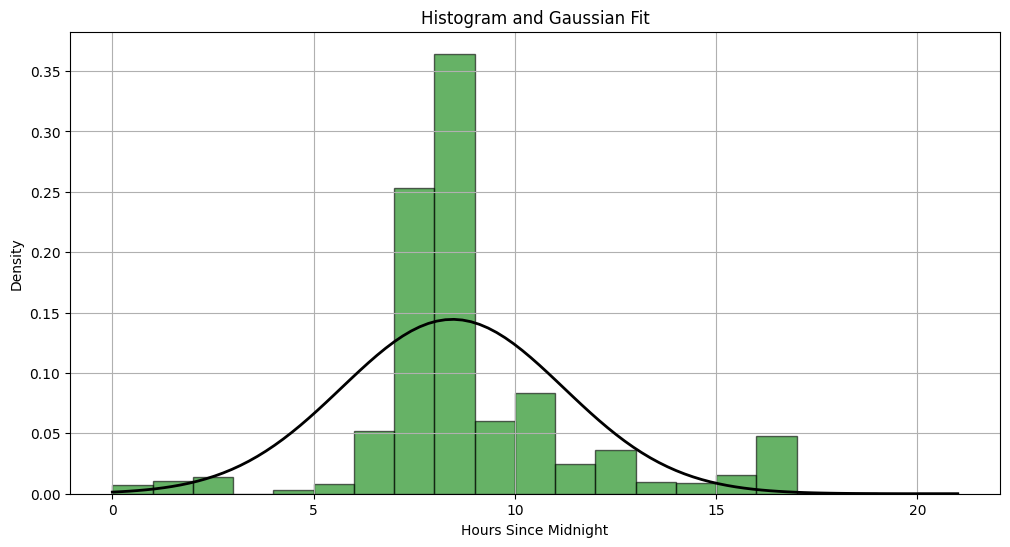

In [22]:
expanded_data = []
for _, row in attendance_df_H.iterrows():
    expanded_data.extend([row['HoursSinceMidnight']] * row['Count'])

expanded_data = np.array(expanded_data)

# Fit Gaussian distribution
mu, std = norm.fit(expanded_data)

# Create a range of values for plotting the Gaussian distribution
xmin, xmax = expanded_data.min(), expanded_data.max()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plot histogram and Gaussian fit
plt.figure(figsize=(12, 6))

# Plot histogram
plt.hist(expanded_data, bins=range(int(xmin), int(xmax) + 1), density=True, alpha=0.6, color='g', edgecolor='black')

# Plot Gaussian distribution
plt.plot(x, p, 'k', linewidth=2)

plt.xlabel('Hours Since Midnight')
plt.ylabel('Density')
plt.title('Histogram and Gaussian Fit')
plt.grid(True)
plt.show()